In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns

In [4]:
# load data
Z = np.load('../data/processed/Z_256.npy')
errors = np.load('../data/processed/transformer_1_errors.npy')
threshold = np.percentile(errors, 99)
anomaly_indices = np.where(errors > threshold)

print(f'Loaded {len(Z)} latent vectors')
print(f'Top 1% threshold: {threshold: .4f}')
print(f'Number of anomalies: {len(anomaly_indices)}')

Loaded 9565 latent vectors
Top 1% threshold:  0.2666
Number of anomalies: 1


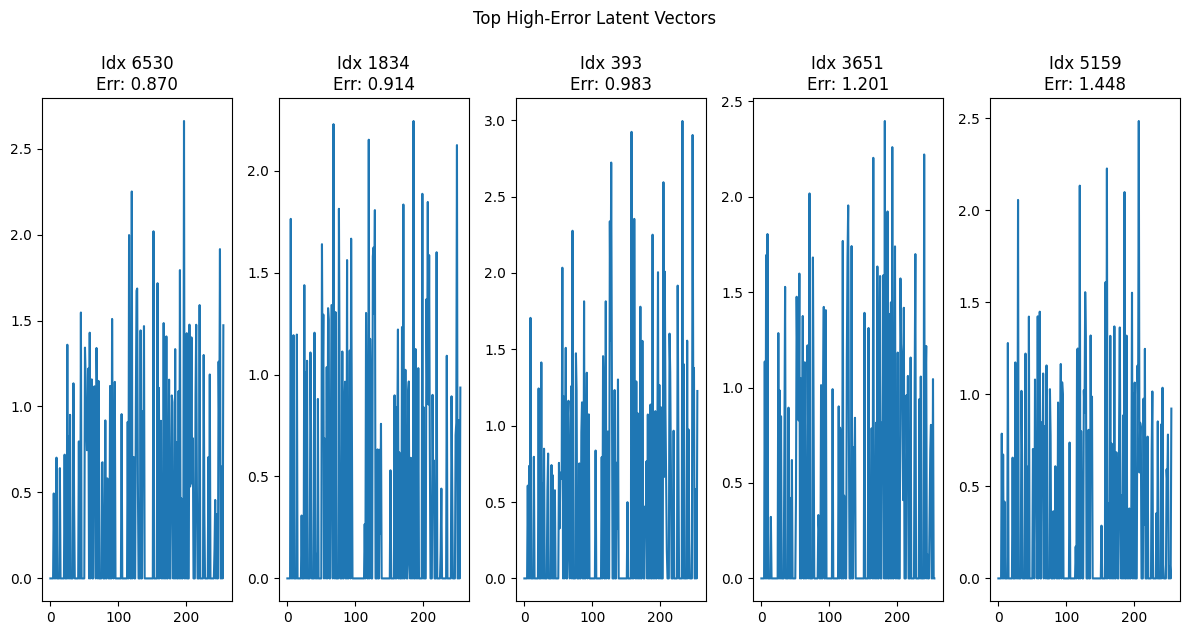

In [5]:
# visualize top anomalies
top_n = 5
top_error_indicies = np.argsort(errors)[-top_n:]

plt.figure(figsize=(12, 6))
for i, idx in enumerate(top_error_indicies):
    plt.subplot(1, top_n, i+1)
    plt.plot(Z[idx])
    plt.title(f'Idx {idx}\nErr: {errors[idx]:.3f}')
    plt.tight_layout()
plt.suptitle("Top High-Error Latent Vectors", y=1.05)
plt.show()

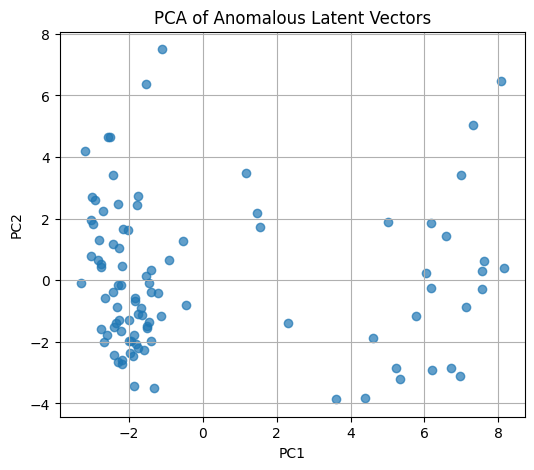

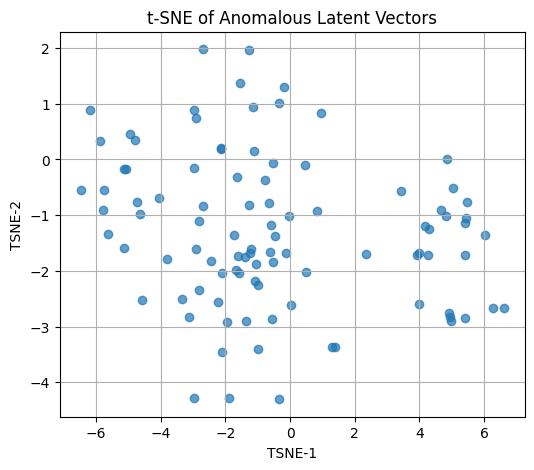

In [6]:
Z_anomalies = Z[anomaly_indices]

# PCA
pca = PCA(n_components=2)
Z_pca = pca.fit_transform(Z_anomalies)

plt.figure(figsize=(6, 5))
plt.scatter(Z_pca[:, 0], Z_pca[:, 1], alpha=0.7)
plt.title("PCA of Anomalous Latent Vectors")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
Z_tsne = tsne.fit_transform(Z_anomalies)

plt.figure(figsize=(6, 5))
plt.scatter(Z_tsne[:, 0], Z_tsne[:, 1], alpha=0.7)
plt.title('t-SNE of Anomalous Latent Vectors')
plt.xlabel('TSNE-1')
plt.ylabel('TSNE-2')
plt.grid(True)
plt.show()